# PHASE 1: SETUP & THE NETWORK

Raw spectrograms contain way too much data for a simple comparison. We need to compress the audio image into a unique "fingerprint." 

To do this, we build a Convolutional Neural Network (CNN). 
* **Layer 1 & 2 (Conv2D):** The AI scans the image looking for basic lines, curves, and edges.
* **Layer 3 & 4 (Conv2D):** The AI combines those lines to recognize complex shapes (like the "drop" of an Atamadaka word).
* **The Output:** The network flattens the image and compresses all that visual data into a single array of 128 numbers. This 128-number array represents the "Pitch Fingerprint."

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Lambda
import tensorflow.keras.backend as K

# Define the exact shape of the Mel-Spectrograms (Height, Width, Channels)
INPUT_SHAPE = (128, 100, 1) 

def build_base_cnn():
    """
    The Feature Extractor. Takes ONE spectrogram and compresses it 
    into a 128-number fingerprint representing the pitch shape.
    """
    model = models.Sequential(name="Spectrogram_Feature_Extractor")
    
    # Block 1: Look for basic edges and lines
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=INPUT_SHAPE, name="Conv_1"))
    model.add(layers.MaxPooling2D((2, 2), name="MaxPool_1"))
    
    # Block 2: Look for complex shapes (arcs, drops)
    model.add(layers.Conv2D(64, (3, 3), activation='relu', name="Conv_2"))
    model.add(layers.MaxPooling2D((2, 2), name="MaxPool_2"))
    
    # Flatten and compress into the final 128-number fingerprint
    model.add(layers.Flatten(name="Flatten_2D_to_1D"))
    model.add(layers.Dense(128, activation='sigmoid', name="Pitch_Fingerprint"))

    
    
    return model

# Create the base brain
base_network = build_base_cnn()



## Phase 2: The Siamese Network
Standard AI tries to classify a single image (example: "Is this a car?"). Our AI needs to answer a different question: "Are these two sounds the same pitch?" 

We use a **Siamese Architecture**:
1. **Two Inputs, One Brain:** We feed Word A and Word B into the exact same Feature Extractor we built in Phase 1. 
2. **The Absolute Difference:** Instead of guessing the pitch, the AI takes the 128-number fingerprint of Word A and literally subtracts the 128-number fingerprint of Word B.
3. **The Final Grade:** A final `Sigmoid` layer looks at those mathematical differences and outputs a final grade from `0.0` (Total Mismatch) to `1.0` (Perfect Match).

In [ ]:
# ==========================================
# PHASE 2: THE SIAMESE ARCHITECTURE
# ==========================================

# 1. Input slots
audio_A = Input(shape=INPUT_SHAPE, name="Word_A_Input")
audio_B = Input(shape=INPUT_SHAPE, name="Word_B_Input")

# 2. Pass both through the base CNN
vector_A = base_network(audio_A)
vector_B = base_network(audio_B)

# 3. The Absolute Difference Layer
# Instead of calculating Euclidean distance, we literally subtract the two 
# 128-number fingerprints to see exactly where they differ.
diff_layer = Lambda(lambda tensors: K.abs(tensors[0] - tensors[1]), name="Absolute_Difference")([vector_A, vector_B])

# 4. Final Decision Layer
# A smart layer that looks at the differences and outputs a Match Probability (0.0 to 1.0)
output = layers.Dense(1, activation="sigmoid", name="Final_Match_Decision")(diff_layer)

siamese_model = Model(inputs=[audio_A, audio_B], outputs=output, name="Siamese_Pitch_Matchmaker")

# ==========================================
# PHASE 3: COMPILATION (STANDARD MATH)
# ==========================================

# Because our final layer is a Sigmoid, we can use the industry-standard 
# binary crossentropy instead of the clunky custom loss function!
siamese_model.compile(
    loss='binary_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

print("FIXED SIAMESE MODEL SUCCESSFULLY COMPILED!")
siamese_model.summary()

FIXED SIAMESE MODEL SUCCESSFULLY COMPILED!


Model: "Siamese_Pitch_Matchmaker"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Word_A_Input        │ (None, 128, 100,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Word_B_Input        │ (None, 128, 100,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Spectrogram_Featur… │ (None, 128)       │  5,671,424 │ Word_A_Input[0][… │
│ (Sequential)        │                   │            │ Word_B_Input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Absolute_Difference │ (None, 128)       │          0 │ Spectrogram_Feat… │
│ (Lambda)            │                   │            │ Spectrogram_Feat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Final_Match_Decisi… │ (None, 1)         │        129 │ Absolute_Differe… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,671,553 (21.64 MB)

 Trainable params: 5,671,553 (21.64 MB)

 Non-trainable params: 0 (0.00 B)

## Phase 3: Data Formatting & Splitting
Before the AI can study, the data must be perfectly uniform. We normalize the decibels to a clean 0 to 1 scale and pad shorter audio clips with empty space so every image is exactly 100 frames wide.

**Unseen Testing Data:** If the AI sees a specific native speaker's voice during training, it might memorize that voice instead of the pitch pattern. To prove the AI is actually smart, we separate 20% of our audio files *before* we generate the pairs. The AI will never see, hear, or interact with these testing files until the final test.

In [ ]:
import os
import numpy as np
import random
from sklearn.model_selection import train_test_split

npy_folder = "./bulk_mel_spectrograms/"
MAX_TIME_STEPS = 100 

def load_and_pad_spectrogram(file_path):
    matrix = np.load(file_path)
    
    # --- NORMALIZE THE DATA ---
    # This squishes all the weird audio decibel math into a clean 0.0 to 1.0 scale
    matrix_min = np.min(matrix)
    matrix_max = np.max(matrix)
    if matrix_max != matrix_min:
        matrix = (matrix - matrix_min) / (matrix_max - matrix_min)
    else:
        matrix = matrix - matrix_min # Fallback if the file is totally silent
    # -----------------------------------

    current_time_steps = matrix.shape[1]
    if current_time_steps < MAX_TIME_STEPS:
        pad_width = MAX_TIME_STEPS - current_time_steps
        return np.pad(matrix, pad_width=((0, 0), (0, pad_width)), mode='constant', constant_values=0)
    elif current_time_steps > MAX_TIME_STEPS:
        return matrix[:, :MAX_TIME_STEPS]
    else:
        return matrix

# --- NEW HELPER FUNCTION ---
def build_pairs_from_dict(data_dict, num_pairs):
    """Takes a dictionary of files and generates balanced pairs from ONLY those files."""
    pairs = []
    labels = []
    categories = list(data_dict.keys())
    half_pairs = num_pairs // 2
    
    # 1. Matches (Positive Pairs)
    for _ in range(half_pairs):
        category = random.choice(categories)
        word_a, word_b = random.sample(data_dict[category], 2)
        pairs.append([word_a, word_b])
        labels.append(1.0)
        
    # 2. Mismatches (Negative Pairs)
    for _ in range(half_pairs):
        cat_1, cat_2 = random.sample(categories, 2)
        word_a = random.choice(data_dict[cat_1])
        word_b = random.choice(data_dict[cat_2])
        pairs.append([word_a, word_b])
        labels.append(0.0)

    # Shuffle
    combined = list(zip(pairs, labels))
    random.shuffle(combined)
    pairs, labels = zip(*combined)
    
    pairs = np.array(pairs)
    return pairs[:, 0], pairs[:, 1], np.array(labels)


print("1. Loading and splitting raw files to prevent Data Leakage...")

# Load everything into a master dictionary
master_buckets = {"Heiban": [], "Atamadaka": [], "Nakadaka": []}
all_files = [f for f in os.listdir(npy_folder) if f.endswith('.npy')]

for filename in all_files:
    filepath = os.path.join(npy_folder, filename)
    matrix = load_and_pad_spectrogram(filepath)
    if "Heiban" in filename: master_buckets["Heiban"].append(matrix)
    elif "Atamadaka" in filename: master_buckets["Atamadaka"].append(matrix)
    elif "Nakadaka" in filename: master_buckets["Nakadaka"].append(matrix)

# Create strict separation dictionaries
train_buckets = {"Heiban": [], "Atamadaka": [], "Nakadaka": []}
test_buckets = {"Heiban": [], "Atamadaka": [], "Nakadaka": []}

# Split the actual files 80/20 BEFORE making pairs
for category, items in master_buckets.items():
    # If we have 100 files, 80 go to train, 20 go to test
    train_files, test_files = train_test_split(items, test_size=0.20, random_state=42)
    train_buckets[category] = train_files
    test_buckets[category] = test_files
    print(f"   - {category}: {len(train_files)} files for training, {len(test_files)} isolated for testing.")

print("\n2. Generating Training Pairs (Using ONLY Training Files)...")
# We generate 1000 pairs using ONLY the 80% training files
X_A_train, X_B_train, Y_train = build_pairs_from_dict(train_buckets, num_pairs=1000)

print("3. Generating Testing Pairs (Using ONLY Hidden Testing Files)...")
# We generate 200 pairs using ONLY the isolated 20% testing files
X_A_test, X_B_test, Y_test = build_pairs_from_dict(test_buckets, num_pairs=200)

print("\nDATASET READY FOR TRAINING!")
print(f"Training Pairs: {len(Y_train)}")
print(f"Testing Pairs:  {len(Y_test)}")

1. Loading and splitting raw files to prevent Data Leakage...
   - Heiban: 240 files for training, 60 isolated for testing.
   - Atamadaka: 240 files for training, 60 isolated for testing.
   - Nakadaka: 240 files for training, 60 isolated for testing.

2. Generating Training Pairs (Using ONLY Training Files)...
3. Generating Testing Pairs (Using ONLY Hidden Testing Files)...

DATASET READY FOR TRAINING!
Training Pairs: 1000
Testing Pairs:  200


## Phase 4: Training & The "Early Stopping" Safety Net
The AI is fed with thousands of pairs and let it adjust its math over 30 rounds (epochs). 

However, AI networks have a bad habit of **Overfitting** (memorizing) the exact pixel patterns of the practice test instead of learning the underlying concept. 
* To prevent this, we use `EarlyStopping`. The code monitors the AI's performance on the hidden 20% validation data. If the AI's score on the unseen data stops improving for 5 rounds in a row, the safety net triggers. It stops the training immediately and rewinds the AI's brain back to its absolute smartest state. 

Finally, we plot the learning curves to visually confirm that the AI actually learned the rules of pitch accent and see progress over time

🚀 INITIATING MODEL TRAINING...

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.5780 - loss: 0.6815 - val_accuracy: 0.6400 - val_loss: 0.6685
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.6490 - loss: 0.6345 - val_accuracy: 0.6500 - val_loss: 0.6643
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.7220 - loss: 0.5668 - val_accuracy: 0.6350 - val_loss: 0.6224
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 176ms/step - accuracy: 0.8250 - loss: 0.4639 - val_accuracy: 0.6800 - val_loss: 0.5901
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 166ms/step - accuracy: 0.8650 - loss: 0.3836 - val_accuracy: 0.7350 - val_loss: 0.5189
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.9220 - loss: 0.2791 - val_accuracy: 0.7250 - val_loss: 0.5196
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.9520 - loss: 0.2168 - val_accuracy: 0.8000 - val_loss: 0.4727
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.9740 -


✅ TRAINING COMPLETE!
💾 Model saved as 'pitch_accent_model.h5'


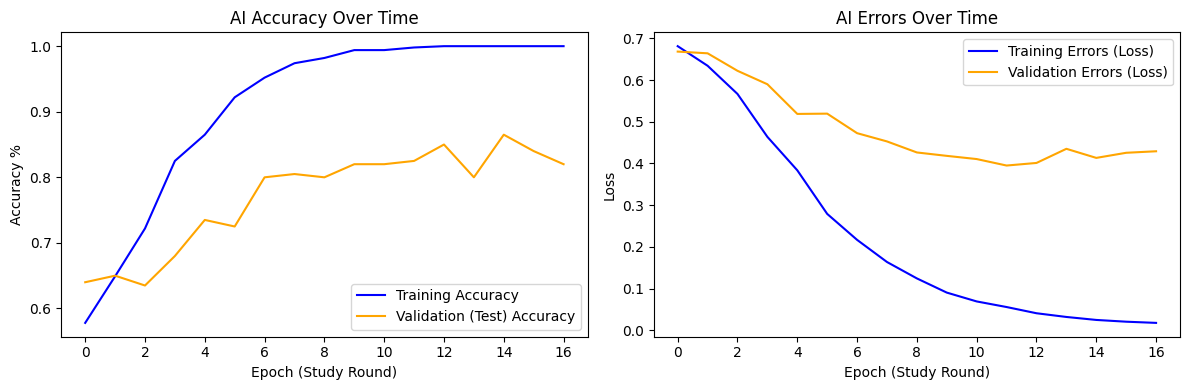

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

print(".........INITIATING MODEL TRAINING...\n")

# --- 1. The Safety Net ---
# Stop training if the Validation Loss doesn't improve for 5 rounds in a row.
# "restore_best_weights" means it will rewind to its smartest state before it overfit.
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# --- 2. Train the Brain ---
# feed it the A/B pairs, and the expected answers (Y).
history = siamese_model.fit(
    [X_A_train, X_B_train], Y_train,
    validation_data=([X_A_test, X_B_test], Y_test),
    epochs=30,           # Maximum number of times it will study the data
    batch_size=32,       # How many pairs it looks at before updating its math
    callbacks=[early_stop]
)

print("\nTRAINING COMPLETE!")

# --- 3. Save the Brain ---
# Save the model so you never have to train it from scratch again
siamese_model.save('pitch_accent_model.h5')
print("Model saved as 'pitch_accent_model.h5'")

# --- 4. Visualize the Learning ---
# Draw a graph to prove it actually learned something and didn't overfit.
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy', color='orange')
plt.title('AI Accuracy Over Time')
plt.xlabel('Epoch (Study Round)')
plt.ylabel('Accuracy %')
plt.legend()

# Plot Loss (Errors)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Errors (Loss)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Errors (Loss)', color='orange')
plt.title('AI Errors Over Time')
plt.xlabel('Epoch (Study Round)')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()